# Time-Aware GAT — Next-Event Prediction on BPI Challenge 2012

This notebook applies the **Time-Aware Dual-GAT** (with exponential attention decay)
to the BPI 2012 dataset.

The BPI 2012 log has long, complex cases with significant temporal variation —
making it a strong test for the time-decay mechanism, which discounts
distant events via **α′ = α · exp(−λ Δt)**.

### Notebook outline
1. Load & Explore
2. Train
3. Evaluate
4. Attention Analysis
5. Summary

In [1]:
from pathlib import Path
import sys, warnings

root = Path.cwd().resolve()
src = root / "src" if (root / "src").exists() else root.parent / "src"
sys.path.insert(0, str(src))
warnings.filterwarnings("ignore", category=FutureWarning)

## 1. Load & Explore the Dataset

In [2]:
import pandas as pd

data_dir = Path.cwd() / "data" if (Path.cwd() / "data").exists() else Path.cwd() / "examples" / "data"
df = pd.read_csv(data_dir / "BPI_Challenge_2012.csv")

df = df.rename(columns={
    "case:concept:name": "case_id",
    "concept:name":      "event",
    "time:timestamp":    "time",
    "lifecycle:transition": "status",
    "case:AMOUNT_REQ":      "amount_req",
})
df = df.dropna(subset=["case_id", "event", "time"]).copy()
df["time"] = pd.to_datetime(df["time"], format="ISO8601", utc=True)
df = df[df.groupby("case_id")["case_id"].transform("size") >= 2].reset_index(drop=True)

lengths = df.groupby("case_id").size()
print(f"Cases: {len(lengths)}  |  Events: {len(df)}  |  Activities: {df['event'].nunique()}")
print(f"Sequence lengths — min: {lengths.min()}, median: {lengths.median():.0f}, max: {lengths.max()}")
df.head()

Cases: 13087  |  Events: 262200  |  Activities: 24
Sequence lengths — min: 3, median: 11, max: 175


,org:resource,status,event,time,case:REG_DATE,case_id,amount_req
0,112.0,COMPLETE,A_SUBMITTED,2011-10-01 00:38:44.546000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
1,112.0,COMPLETE,A_PARTLYSUBMITTED,2011-10-01 00:38:44.880000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
2,112.0,COMPLETE,A_PREACCEPTED,2011-10-01 00:39:37.906000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
3,112.0,SCHEDULE,W_Completeren aanvraag,2011-10-01 00:39:38.875000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
4,NaN,START,W_Completeren aanvraag,2011-10-01 11:36:46.437000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000


## 2. Train the Model

In [3]:
from timegnn import gat_time_decay

result = gat_time_decay(
    df,
    case_col="case_id",
    event_col="event",
    time_col="time",
    cat_event=["event"],
    num_event=[],
    seq_cols=["amount_req"],
    cat_seq=[],
    num_seq=["amount_req"],
    num_epochs=3,
    batch_size=16,
)

model = result["model"]
pd.DataFrame(result["history"])

,epoch,train_loss,train_acc,test_loss,test_acc
0,1,0.863602,0.773061,0.702852,0.809496
1,2,0.689501,0.802747,0.627536,0.804102
2,3,0.706568,0.799854,0.619934,0.808414


## 3. Evaluate with Comprehensive Metrics

In [4]:
import torch
from torch.utils.data import DataLoader
from timegnn import (
    EventLogTransformer, top_k_accuracy, predict, predict_per_sequence,
    average_bleu_score, compute_dls_and_exact_match, analyze_sequence_errors,
)
from timegnn.data.pyg import CustomDataset, custom_collate_fn

transformer = EventLogTransformer(
    case_col="case_id", event_col="event", time_col="time",
    cat_event=["event"], num_event=[],
    seq_cols=["amount_req"], cat_seq=[], num_seq=["amount_req"],
    mode="gat_time_decay",
).fit(df)

transformed = transformer.transform(df)
dataset = CustomDataset(transformed.event_features, transformed.labels)
loader  = DataLoader(dataset, batch_size=16, shuffle=False, collate_fn=custom_collate_fn)

device = "cuda" if torch.cuda.is_available() else "cpu"
model  = model.to(device)

preds_flat, labels_flat, outputs = predict(model, loader, device)
print(f"Top-1 accuracy: {top_k_accuracy(outputs, labels_flat, k=1):.4f}")
print(f"Top-3 accuracy: {top_k_accuracy(outputs, labels_flat, k=3):.4f}")
print(f"Top-5 accuracy: {top_k_accuracy(outputs, labels_flat, k=5):.4f}")

preds_seq, labels_seq = predict_per_sequence(model, loader, device)
bleu = average_bleu_score(preds_seq, labels_seq)
dls, exact = compute_dls_and_exact_match(preds_seq, labels_seq)
print(f"\nBLEU:  {bleu:.4f}")
print(f"DLS:   {dls:.4f}")
print(f"Exact: {exact:.4f}")

print("\nSequence error summary:")
print(analyze_sequence_errors(model, loader, device))

Top-1 accuracy: 0.8037
Top-3 accuracy: 0.9630
Top-5 accuracy: 0.9922

BLEU:  0.4640
DLS:   0.7659
Exact: 0.0000

Sequence error summary:
(array([    0, 13087,     0,  2740,  2069,  1658,  1068,  1470,   874,
         831,   516,   520,   864,   370,   922,   414,   990,   749,
         946,   776,   987,   877,   910,   900,   894,   888,   792,
         740,   747,   716,   648,   631,   629,   592,   575,   522,
         531,   445,   461,   434,   400,   366,   366,   350,   312,
         299,   283,   249,   253,   249,   203,   214,   199,   184,
         171,   132,   140,   138,   126,   101,   104,   110,    83,
          85,   101,   100,    83,    81,    70,    67,    68,    59,
          74,    53,    47,    49,    50,    48,    43,    33,    28,
          34,    31,    24,    21,    20,    15,    17,    16,    14,
          14,    19,    10,    13,    11,    17,    13,    11,    17,
           5,     4,    11,    10,     7,     6,    14,     9,     8,
           8,     8,  

## 4. Attention Analysis & Visualisations

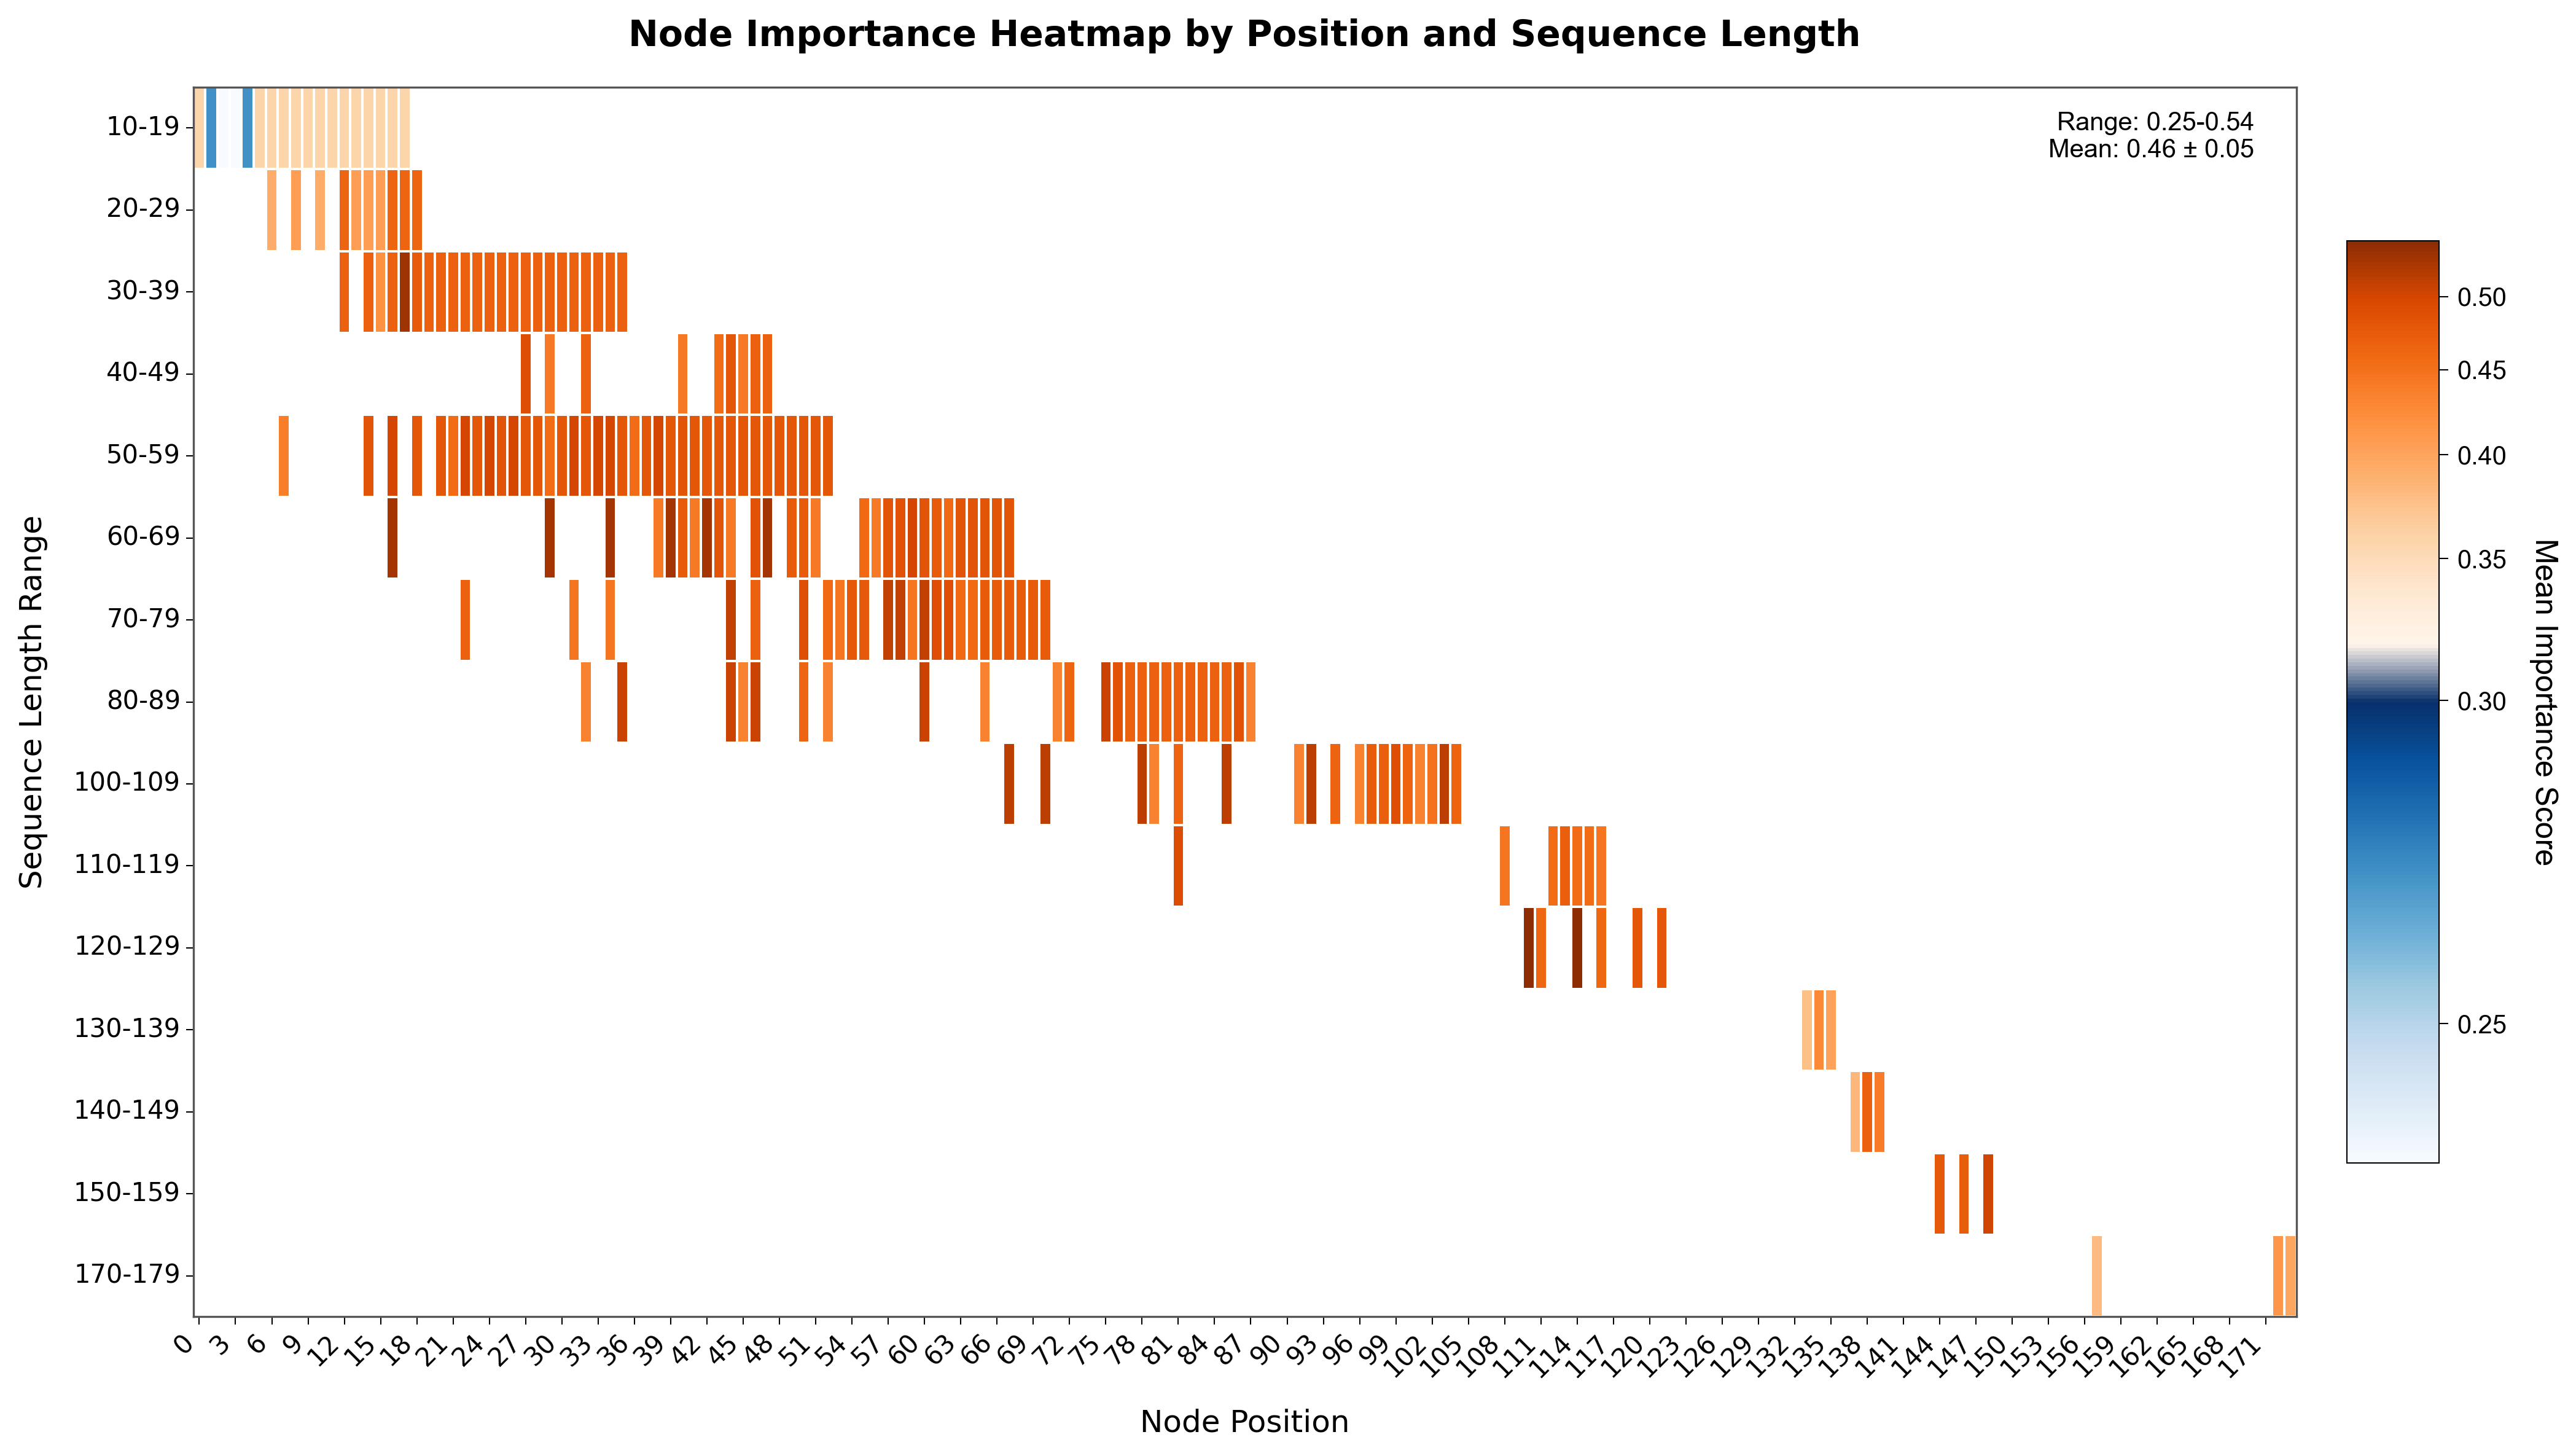

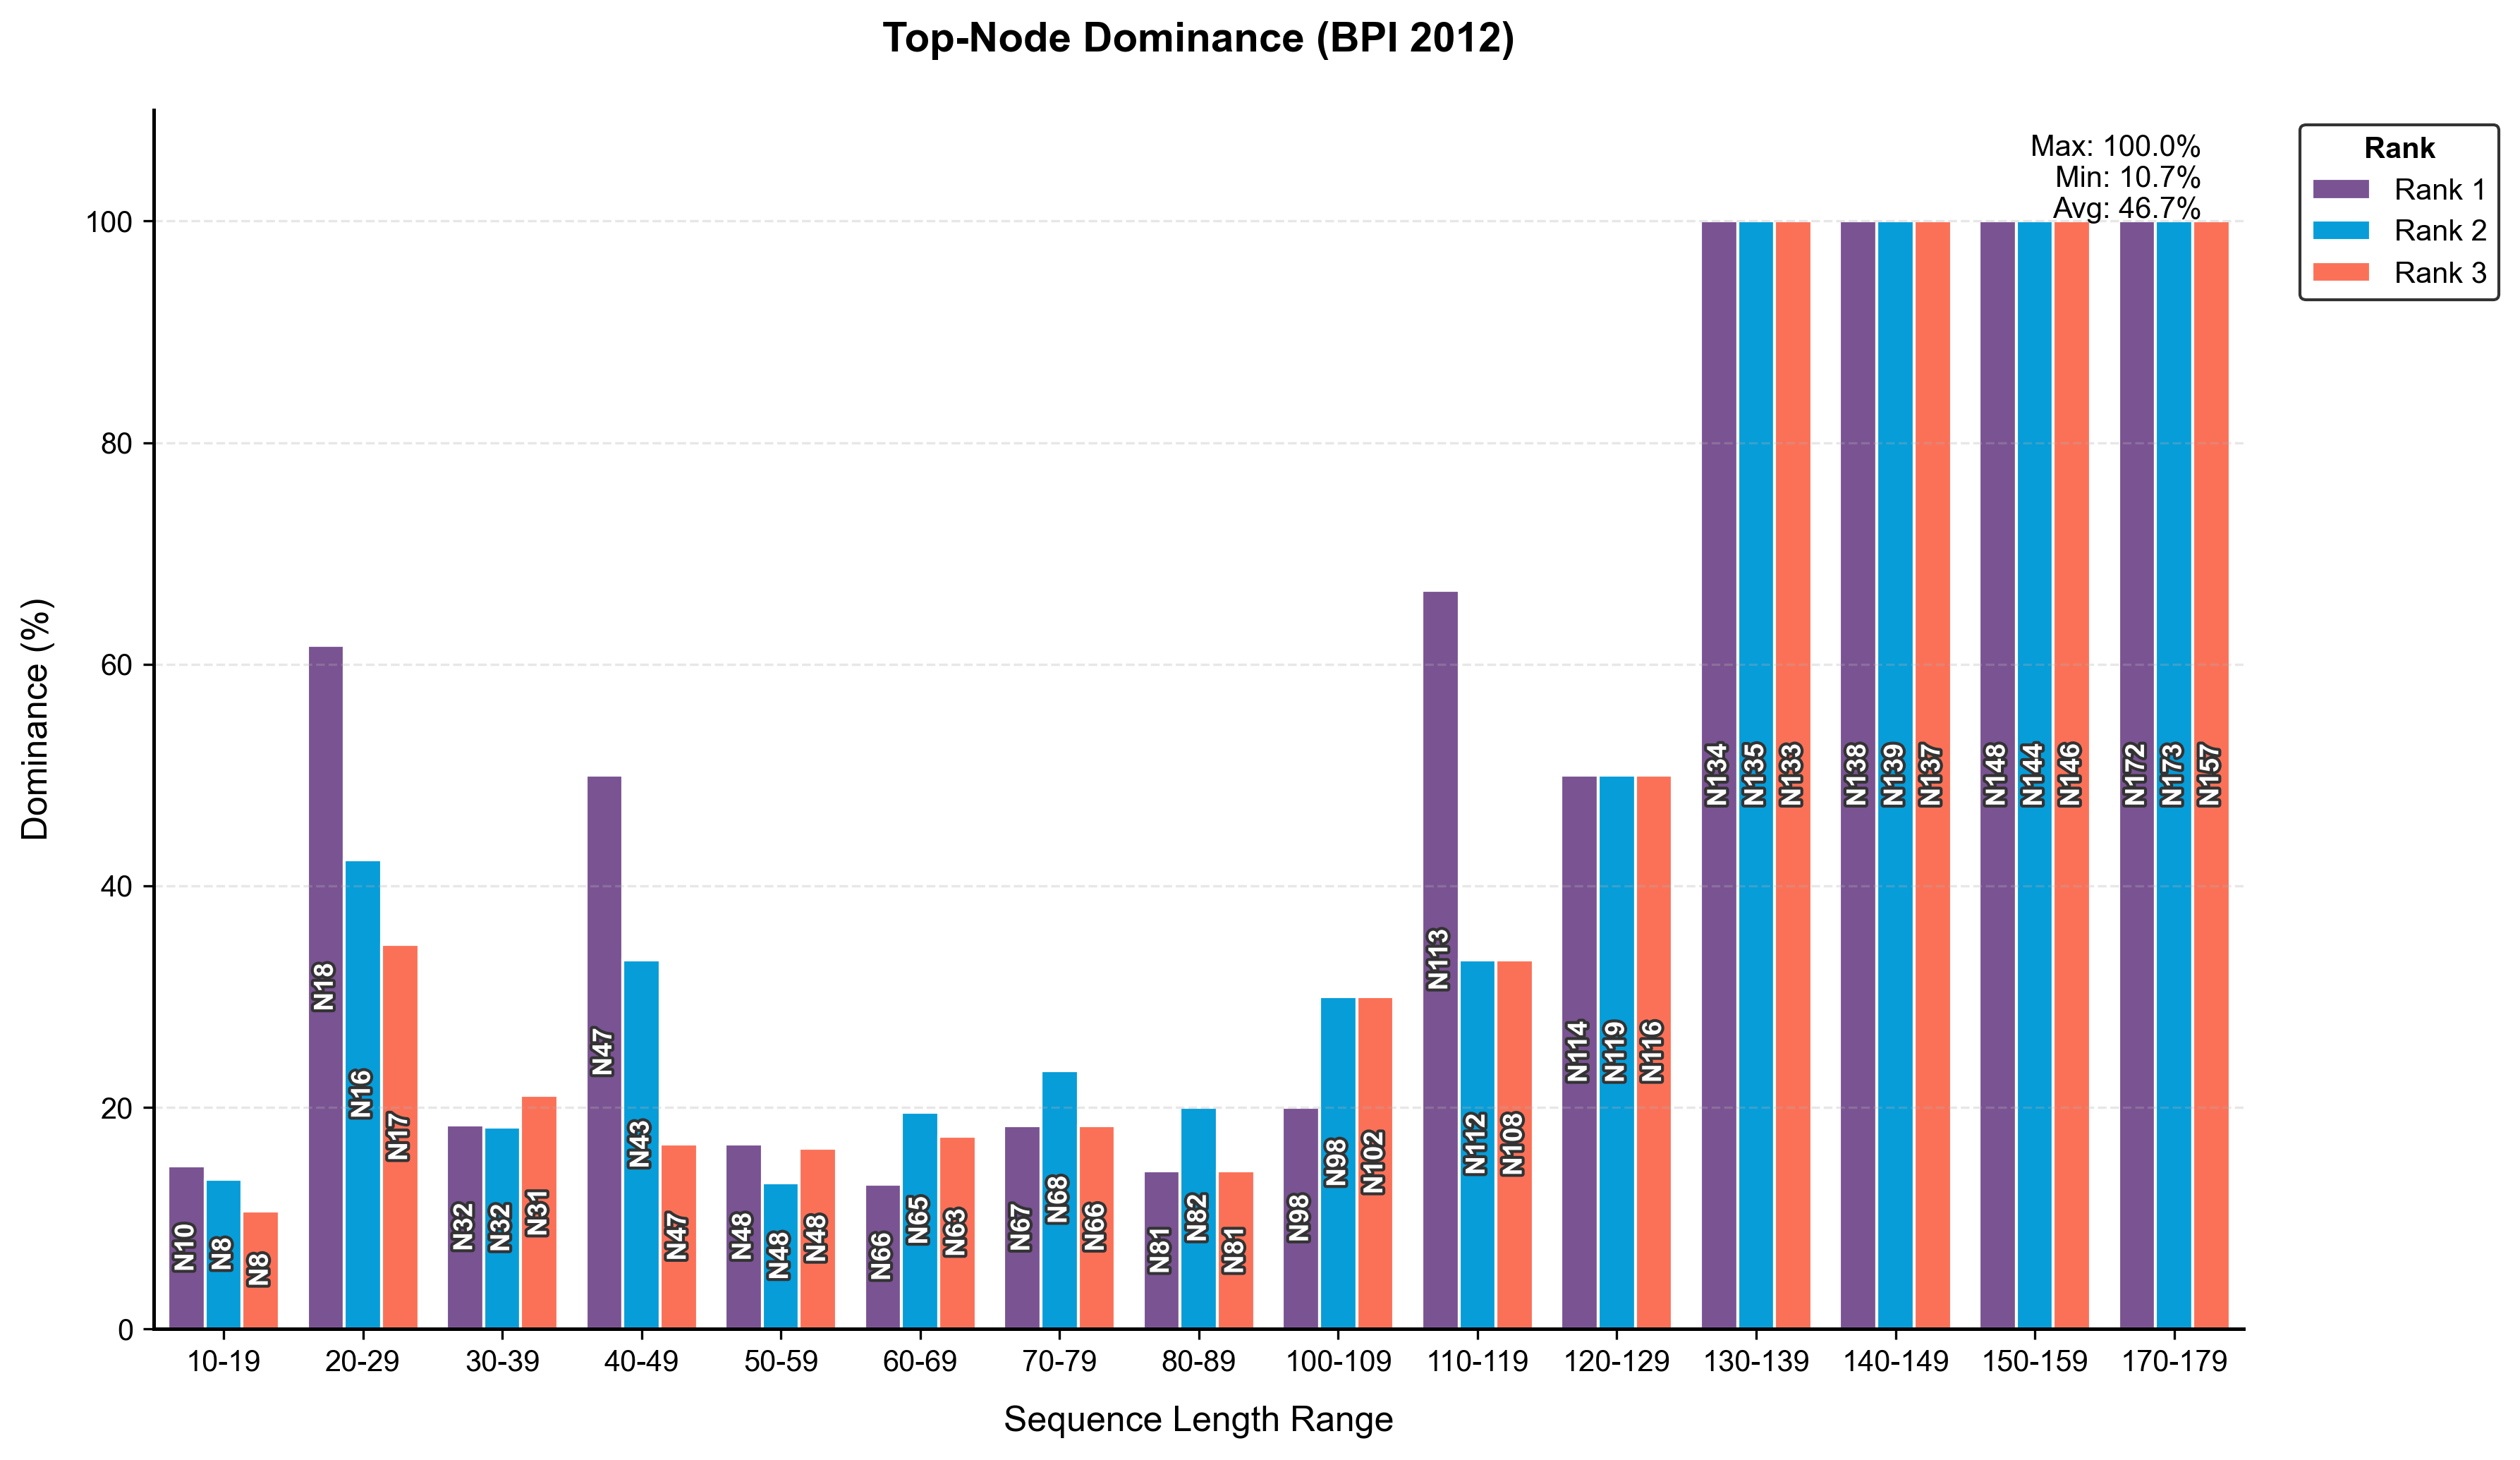

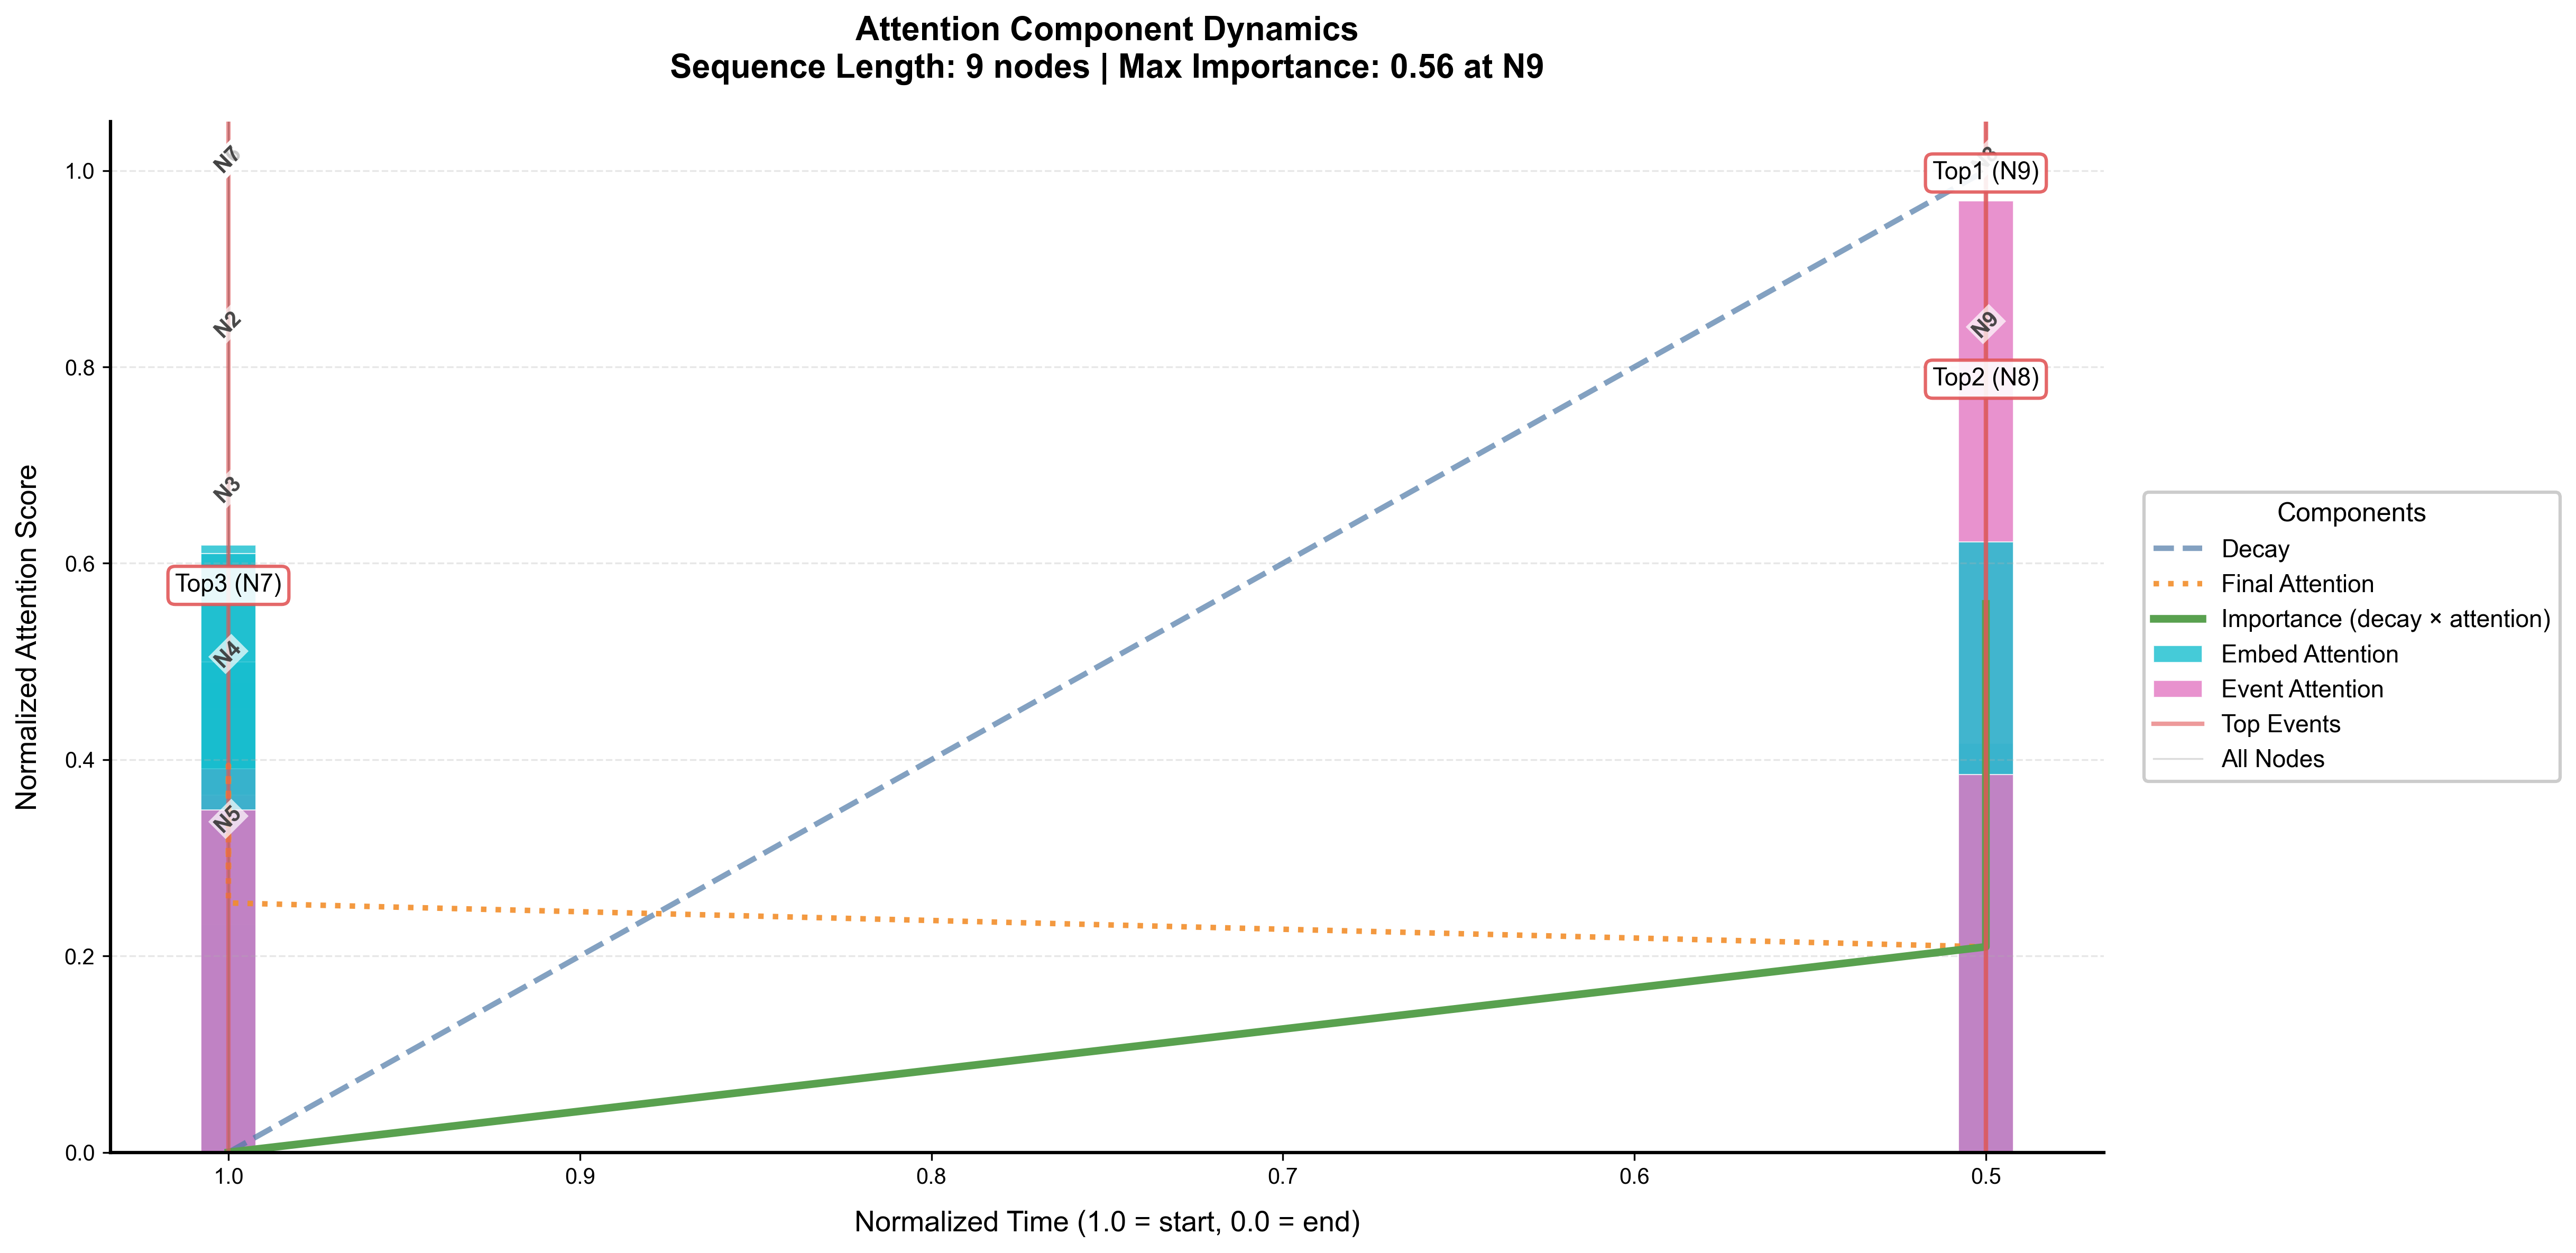

<Figure size 640x480 with 0 Axes>

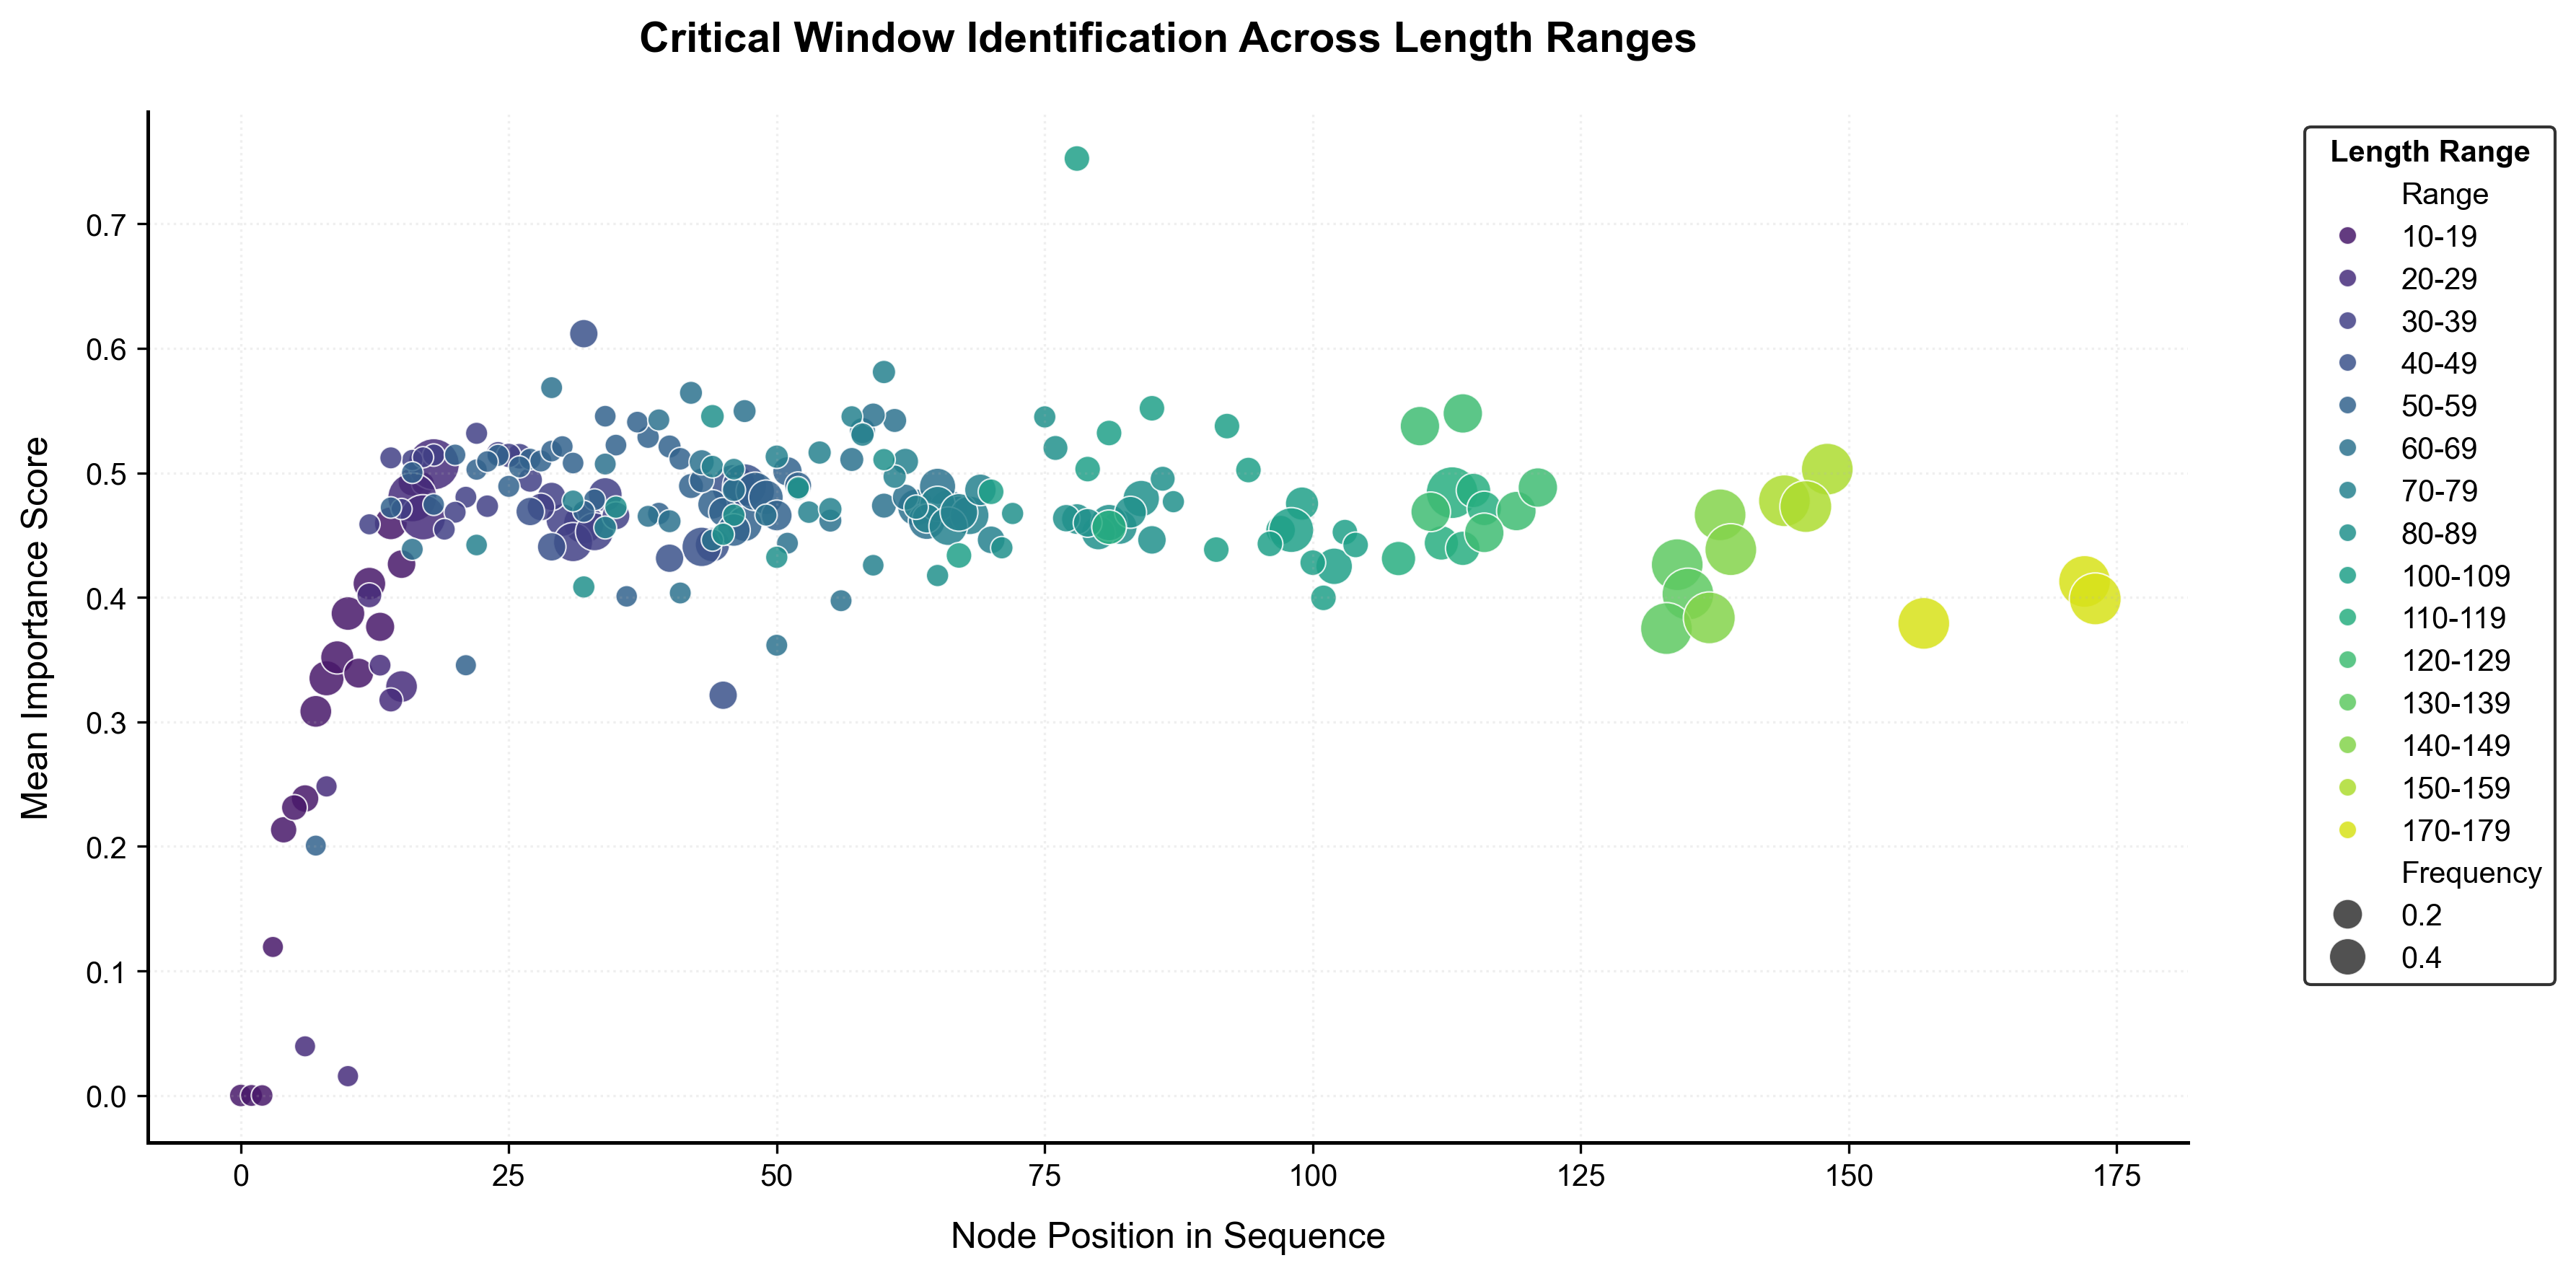

       Comparison Mean Diff t-statistic    p-value Cohen's d Significance  n1  \
3  10-19 vs 50-59    -0.194       -6.39  4.252e-08     -1.84           **  18   
4  10-19 vs 60-69    -0.195       -5.87  5.290e-07     -1.77           **  18   
5  10-19 vs 70-79    -0.198       -5.73  1.120e-06     -1.79           **  18   
1  10-19 vs 30-39    -0.197       -5.65  1.583e-06     -1.78           **  18   
6  10-19 vs 80-89    -0.182       -5.28  4.783e-06     -1.65           **  18   

   n2  
3  37  
4  28  
5  24  
1  23  
6  24  


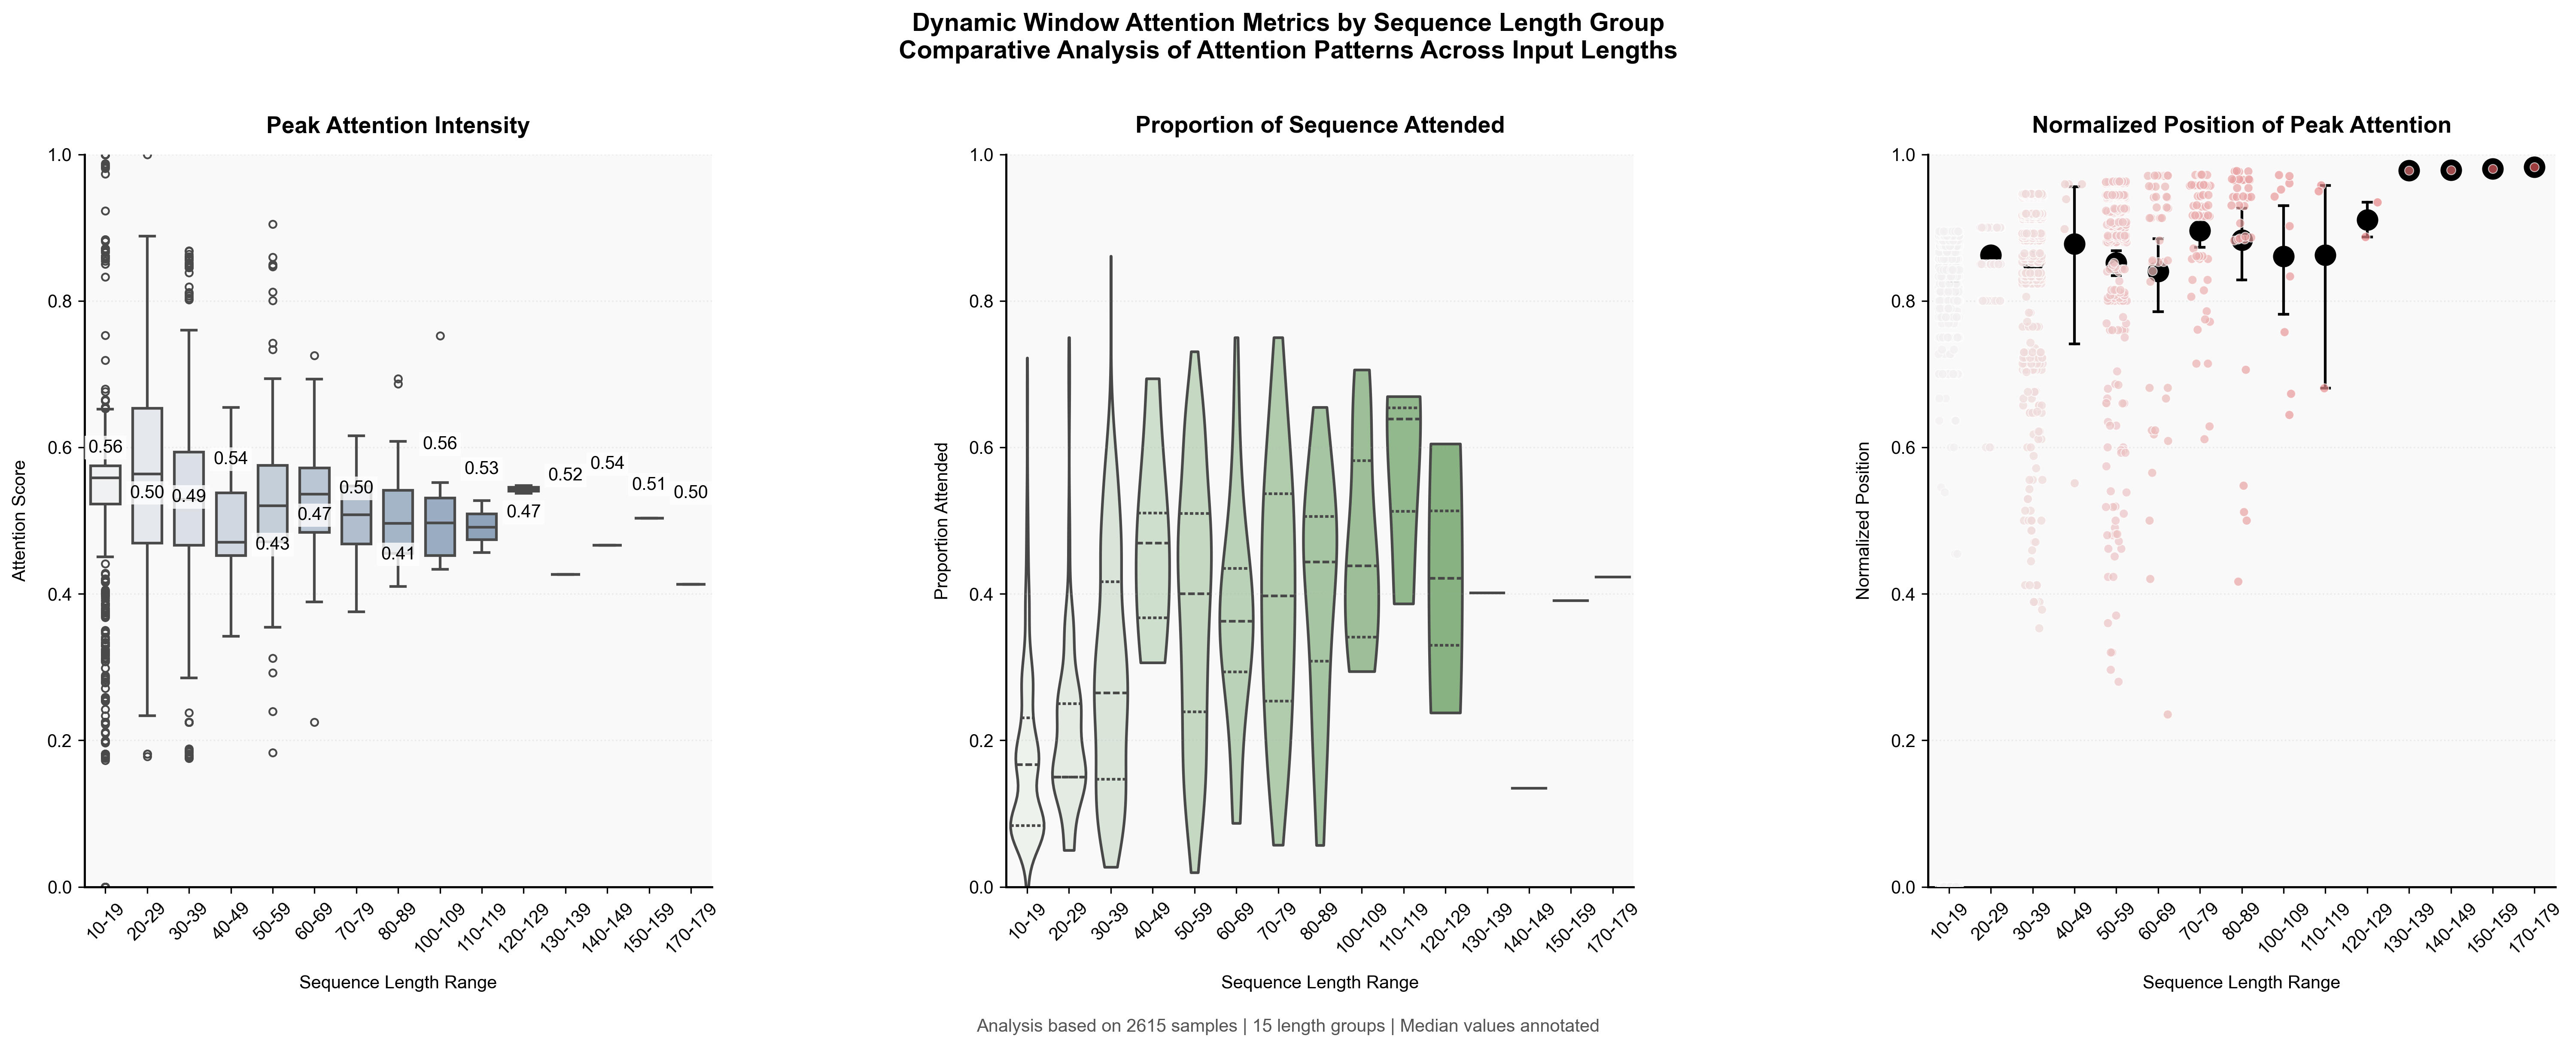

In [5]:
from timegnn import (
    get_length_bins_from_attention, compute_importance_stats,
    plot_heatmap_from_stats, plot_rank_dominance,
    plot_importance_timeline,
    plot_critical_windows, generate_pairwise_ttest_table,
    get_top_significant_ranges,
    calculate_window_metrics, plot_window_metrics,
)

attention = result.get("attention")

if attention:
    length_bins, _ = get_length_bins_from_attention(attention, bin_size=10)
    range_stats, range_importances, _ = compute_importance_stats(attention, length_bins)

    plot_heatmap_from_stats(range_stats, range_importances)
    plot_rank_dominance(range_stats, title="Top-Node Dominance (BPI 2012)")
    plot_importance_timeline(attention, min_length=5, max_length=20)

    window_stats = plot_critical_windows(attention, length_bins, compare_ranges=None)
    pairwise = generate_pairwise_ttest_table(window_stats, length_bins)
    top_sig, _ = get_top_significant_ranges(pairwise, num_top=5)
    print(top_sig)

    df_metrics = calculate_window_metrics(attention, length_bins)
    plot_window_metrics(df_metrics)
else:
    print("No attention data was returned.")

## 5. Summary

On BPI 2012, the time-decay model can learn how far back in a loan-application
process the model needs to look. The attention analysis may reveal that
recent events dominate (strong decay) or that early events (e.g. initial submission)
remain important throughout the process.